# Exercise 4: Community detection on the network of Computational Social Scientists

In [19]:
from collections import defaultdict, Counter
from community import community_louvain   # <- changed
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
from tqdm import tqdm
import networkx as nx
import pandas as pd
import numpy as np
import random
import ast

## Build the Computational Social Scientists network

In [12]:
df = pd.read_csv('../Week5/D2_temp_papers.csv')
df['author_ids'] = df['author_ids'].apply(ast.literal_eval)

G = nx.Graph()
for _, row in df.iterrows():
    authors = row['author_ids']
    for i in range(len(authors)):
        for j in range(i + 1, len(authors)):
            if authors[i] and authors[j]:
                G.add_edge(authors[i].strip(), authors[j].strip())

print(f'Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}')

Nodes: 466, Edges: 1202


## Louvain community detection
Use the Python Louvain-algorithm implementation to find communities. Report number of communities, their sizes, and the modularity.

In [13]:
partition = community_louvain.best_partition(G)

num_communities = max(partition.values()) + 1
community_sizes = Counter(partition.values())

print(f'Number of communities: {num_communities}')
print(f'\nCommunity sizes:')
for comm_id, size in sorted(community_sizes.items(), key=lambda x: -x[1]):
    print(f'  Community {comm_id}: {size} nodes')

Number of communities: 13

Community sizes:
  Community 6: 144 nodes
  Community 3: 76 nodes
  Community 4: 47 nodes
  Community 9: 39 nodes
  Community 0: 38 nodes
  Community 11: 34 nodes
  Community 8: 29 nodes
  Community 1: 18 nodes
  Community 10: 16 nodes
  Community 7: 11 nodes
  Community 2: 7 nodes
  Community 5: 5 nodes
  Community 12: 2 nodes


In [14]:
modularity = community_louvain.modularity(partition, G)
print(f'Modularity (Louvain): {modularity:.4f}')

Modularity (Louvain): 0.7756


## Is the modularity significantly different from 0?
We use a randomization test with degree-preserving edge swaps to build a null distribution of modularity values.

In [15]:
def double_edge_swap(G):
    G_copy = G.copy()
    edges = list(G_copy.edges())
    E = len(edges)
    num_swaps = E * 10
    swaps_done = 0
    while swaps_done < num_swaps:
        e1, e2 = random.sample(edges, 2)
        a, b = e1
        c, d = e2
        if random.random() < 0.5:
            a, b = b, a
        if len(set([a, b, c, d])) == 4:
            if not G_copy.has_edge(a, d) and not G_copy.has_edge(c, b):
                G_copy.remove_edge(*e1)
                G_copy.remove_edge(*e2)
                G_copy.add_edge(a, d)
                G_copy.add_edge(c, b)
                edges.remove(e1)
                edges.remove(e2)
                edges.append((a, d))
                edges.append((c, b))
                swaps_done += 1
    return G_copy

In [16]:
random_modularities = []
for i in range(100):
    G_rand = double_edge_swap(G)
    rand_partition = community_louvain.best_partition(G_rand)
    rand_mod = community_louvain.modularity(rand_partition, G_rand)
    random_modularities.append(rand_mod)

print(f'Random modularity — Mean: {np.mean(random_modularities):.4f}, Std: {np.std(random_modularities):.4f}')
print(f'Actual modularity: {modularity:.4f}')
print(f'Z-score: {(modularity - np.mean(random_modularities)) / np.std(random_modularities):.2f}')

Random modularity — Mean: 0.4039, Std: 0.0046
Actual modularity: 0.7756
Z-score: 81.15


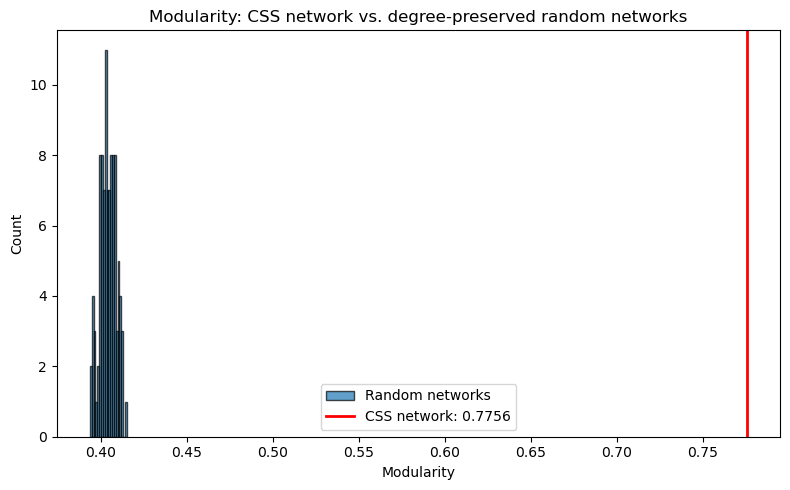

In [17]:
plt.figure(figsize=(8, 5))
plt.hist(random_modularities, bins=20, edgecolor='black', alpha=0.7, label='Random networks')
plt.axvline(modularity, color='red', linewidth=2, label=f'CSS network: {modularity:.4f}')
plt.xlabel('Modularity')
plt.ylabel('Count')
plt.title('Modularity: CSS network vs. degree-preserved random networks')
plt.legend()
plt.tight_layout()
plt.show()

The modularity of the CSS network is significantly higher than what we observe in degree-preserved random networks. The actual modularity falls far outside the null distribution, confirming that the community structure detected by Louvain is statistically significant and not an artifact of the degree distribution. The high Z-score means the probability of observing this modularity by chance is essentially zero.

## Visualize the network with communities (netwulf)
Color each node based on its community assignment.

In [20]:
import netwulf as nw

# Assign community as node attribute for netwulf coloring
for node in tqdm(G.nodes()):
    G.nodes[node]['group'] = partition[node]

nw.visualize(G)

100%|██████████| 466/466 [00:00<00:00, 1849144.43it/s]
/opt/homebrew/Caskroom/miniconda/base/envs/new_base/lib/python3.11/site-packages/networkx/readwrite/json_graph/node_link.py:142: FutureWarning: 
The default value will be `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_data(G, edges="links") to preserve current behavior, or
  nx.node_link_data(G, edges="edges") for forward compatibility.
  warnings.warn(


(None, None)

### Static matplotlib visualization

/var/folders/xk/h5gq47r943g54w8rgn1d1hwh0000gn/T/ipykernel_60112/4247331955.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', num_communities)


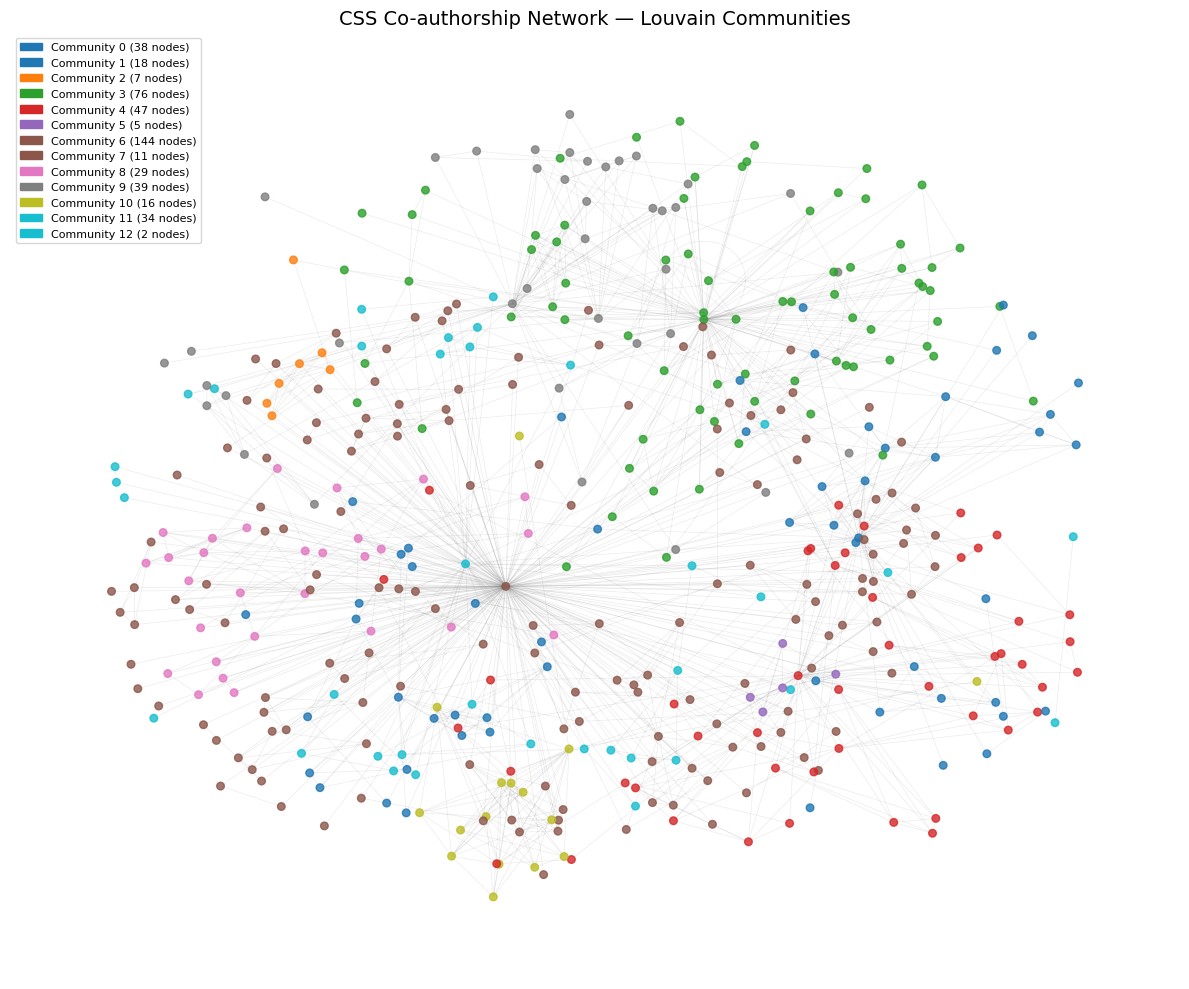

In [21]:
pos = nx.spring_layout(G, seed=42, k=0.3)

cmap = cm.get_cmap('tab10', num_communities)
node_colors = [cmap(partition[node]) for node in G.nodes()]

fig, ax = plt.subplots(figsize=(12, 10))
nx.draw_networkx_edges(G, pos, alpha=0.15, edge_color='gray', width=0.5, ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=30, alpha=0.8, ax=ax)

patches = [mpatches.Patch(color=cmap(i), label=f'Community {i} ({community_sizes[i]} nodes)')
           for i in range(num_communities)]
ax.legend(handles=patches, loc='upper left', fontsize=8)
ax.set_title('CSS Co-authorship Network — Louvain Communities', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.savefig('css_communities.png', dpi=150, bbox_inches='tight')
plt.show()

### Structure observed
The visualization reveals clear community structure in the CSS co-authorship network. Nodes of the same color (community) tend to cluster together, with relatively few edges crossing between communities. This is consistent with the high modularity score — researchers within the same community collaborate much more densely with each other than with researchers in other communities. The communities likely reflect sub-fields or close research groups within computational social science.

## Save the assignment of authors to communities

In [34]:
community_df = pd.DataFrame([
    {'author_id': node, 'community': comm}
    for node, comm in partition.items()
])
community_df.to_csv('author_communities.csv', index=False)
print(f'Saved {len(community_df)} author-community assignments to author_communities.csv')
community_df.head(10)

Saved 466 author-community assignments to author_communities.csv


,author_id,community
0,https://openalex.org/A5090665793,0
1,https://openalex.org/A5113226689,0
2,https://openalex.org/A5058815871,3
3,https://openalex.org/A5040821463,3
4,https://openalex.org/A5000679279,3
5,https://openalex.org/A5082742221,0
6,https://openalex.org/A5002798141,0
7,https://openalex.org/A5031463408,0
8,https://openalex.org/A5041923525,0
9,https://openalex.org/A5020189261,0


In [35]:
# Degrees of authors and merging with community assignments
degree_df = pd.DataFrame([
    {'author_id': node, 'degree': deg}
    for node, deg in G.degree()
])
community_df = community_df.merge(degree_df, on='author_id')
community_df.to_csv('author_communities.csv', index=False)